In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%bash
# 1. Zipi Drive'dan yerel diske kopyala (Çok daha hızlıdır)
cp "/content/drive/MyDrive/dataset_lip.zip" /content/dataset_lip.zip

# 2. Yerel diske çıkar
unzip -q /content/dataset_lip.zip -d /content/dataset_processed

echo "--- VERİ SETİ YEREL DİSKE TAŞINDI VE AÇILDI ---"

--- VERİ SETİ YEREL DİSKE TAŞINDI VE AÇILDI ---


In [ ]:
import os
import re
from sklearn.model_selection import train_test_split

data_path = '/content/dataset_processed/dataset_lip'
all_data = []

# Hem mov hem mp4, hem de 'data' klasörlerini yakalayan regex
person_pattern = re.compile(r'data\d+')

for root, dirs, files in os.walk(data_path):
    for file in files:
        # Uzantı kontrolü (.mov veya .mp4)
        if file.lower().endswith(('.mov', '.mp4')):
            full_path = os.path.join(root, file)
            parts = full_path.split(os.sep)

            # Person ID: Yolun içindeki 'dataXX' klasörünü bul
            person = next((p for p in parts if person_pattern.match(p)), None)
            # Label: Videonun bulunduğu klasör (Örn: buzdolabı)
            label = parts[-2]

            if person and label:
                all_data.append({
                    'path': full_path,
                    'person': person,
                    'label': label
                })

if len(all_data) == 0:
    print("❌ Hiç video bulunamadı. Lütfen 'dataset_lip' klasörünün yolunu kontrol et.")
else:
    person_ids = sorted(list(set([d['person'] for d in all_data])))
    labels_set = sorted(list(set([d['label'] for d in all_data])))
    label2idx = {label: i for i, label in enumerate(labels_set)}

    print(f"✅ OPERASYON TAMAMLANDI!")
    print(f"---" * 10)
    print(f"Bulunan Toplam Video: {len(all_data)}")
    print(f"Tespit Edilen Kişi Sayısı: {len(person_ids)} (Hedef: 73)")
    print(f"Tespit Edilen Kelime Sayısı: {len(labels_set)}")

    # Kişi listesini kontrol edelim
    if len(person_ids) < 73:
        print(f"⚠️ Hala {73 - len(person_ids)} kişi eksik. İlk 5: {person_ids[:5]} - Son 5: {person_ids[-5:]}")
    else:
        print("🎉 73 kişinin tamamı (veya daha fazlası) bulundu!")

✅ OPERASYON TAMAMLANDI!
------------------------------
Bulunan Toplam Video: 11994
Tespit Edilen Kişi Sayısı: 73 (Hedef: 73)
Tespit Edilen Kelime Sayısı: 60
🎉 73 kişinin tamamı (veya daha fazlası) bulundu!


In [ ]:
# Tüm hatalı etiketleri doğru olanlarla eşleştiriyoruz
clean_mapping = {
    'budolabı': 'buzdolabı',
    'naıslsın': 'nasılsın',
    'vapur)': 'vapur',
    'ıyuncak': 'oyuncak',
    'pastane': 'postane' # Zeynep, pastane artık postane oldu!
}

# Veriyi temizle
for d in all_data:
    if d['label'] in clean_mapping:
        d['label'] = clean_mapping[d['label']]

# Yeni etiket setini oluştur (Tam 55 kelime)
labels_set = sorted(list(set([d['label'] for d in all_data])))
label2idx = {label: i for i, label in enumerate(labels_set)}

print(f"✅ TEMİZLİK TAMAMLANDI!")
print(f"Sınıf Sayısı: {len(labels_set)} (Hedeflenen 55'e ulaşıldı mı?: {'EVET' if len(labels_set)==55 else 'HAYIR'})")

✅ TEMİZLİK TAMAMLANDI!
Sınıf Sayısı: 55 (Hedeflenen 55'e ulaşıldı mı?: EVET)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Eğer yukarıda tanımlamadıysan cihazı tekrar set edelim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Sistem hazır. Cihaz: {device}")

✅ Sistem hazır. Cihaz: cuda


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import os

# 1. 73 Kişiyi 80-10-10 bölüyoruz
train_ids, temp_ids = train_test_split(person_ids, test_size=0.20, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=42)

train_list = [d for d in all_data if d['person'] in train_ids]
val_list = [d for d in all_data if d['person'] in val_ids]
test_list = [d for d in all_data if d['person'] in test_ids]

class MaskedLipDataset(LipVideoDataset):
    def __getitem__(self, idx):
        # Üst sınıftan frames (Padding dahil) ve label alınıyor
        frames, label = super().__getitem__(idx)

        # Maskeleme için gerçek kare sayısını bul (Tamamen siyah olmayanlar)
        # frames: [Time(75), Channels(3), 96, 96]
        valid_frames = (frames.sum(dim=(1, 2, 3)) != 0).long()
        actual_length = valid_frames.sum().item()

        # Eğer video tamamen boşsa (hata olmasın diye) en az 1 kare kabul et
        actual_length = max(1, actual_length)

        return frames, label, actual_length

# DataLoader'lar
train_loader = DataLoader(MaskedLipDataset(train_list, label2idx, seq_max=75), batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(MaskedLipDataset(val_list, label2idx, seq_max=75), batch_size=8, shuffle=False)

print(f"✅ 80-10-10 Hazır! Eğitim: {len(train_ids)} kişi, Val: {len(val_ids)} kişi, Test: {len(test_ids)} kişi.")

✅ 80-10-10 Hazır! Eğitim: 58 kişi, Val: 7 kişi, Test: 8 kişi.


In [ ]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class LipVideoDataset(Dataset):
    def __init__(self, data_list, label2idx, seq_max=75):
        self.data_list = data_list
        self.label2idx = label2idx
        self.seq_max = seq_max

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        video_info = self.data_list[idx]
        cap = cv2.VideoCapture(video_info['path'])
        frames = []
        while len(frames) < self.seq_max:
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.resize(frame, (96, 96))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()

        while len(frames) < self.seq_max:
            frames.append(np.zeros((96, 96, 3), dtype=np.uint8))

        frames = np.array(frames)
        frames = torch.FloatTensor(frames).permute(0, 3, 1, 2)
        label = self.label2idx[video_info['label']]
        return frames, torch.tensor(label)

class MaskedLipDataset(LipVideoDataset):
    def __getitem__(self, idx):
        frames, label = super().__getitem__(idx)
        frames = frames / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        frames = (frames - mean) / std
        actual_length = max(1, (frames.abs().sum(dim=(1,2,3)) > 0.001).sum().item())
        return frames, label, actual_length

In [ ]:
import torch
import gc

# GPU belleğini ve Python çöp toplayıcısını temizle
torch.cuda.empty_cache()
gc.collect()

# Eğer hala düzelmezse Runtime -> Restart Session yapman en temizidir.

14112

In [ ]:
import torch.nn as nn
from torchvision import models

class modernHybridLipModel(nn.Module):
    def __init__(self, num_classes=55):
        super().__init__()
        convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        self.feature_extractor = convnext.features
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.feature_dim = 768
        self.pos_embedding = nn.Parameter(torch.randn(1, 75, self.feature_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=768, nhead=8, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x, lengths):
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        features = self.feature_extractor(x)
        features = self.avgpool(features).view(b, t, self.feature_dim)
        features = features + self.pos_embedding[:, :t, :]
        mask = torch.arange(t).to(x.device)[None, :] >= lengths[:, None]
        x = self.transformer(features, src_key_padding_mask=mask)
        outputs = torch.stack([x[i, :lengths[i]].mean(dim=0) for i in range(b)])
        return self.classifier(outputs)

In [ ]:
import torch
import os
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = modernHybridLipModel(num_classes=55).to(device)

for param in model.feature_extractor.parameters():
    param.requires_grad = False

train_loader = DataLoader(MaskedLipDataset(train_list, label2idx, seq_max=75), batch_size=16, shuffle=True)
val_loader = DataLoader(MaskedLipDataset(val_list, label2idx, seq_max=75), batch_size=16, shuffle=False)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scaler = torch.amp.GradScaler('cuda')
checkpoint_dir = '/content/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
best_val_acc = 0.0

In [ ]:
import torch
import torch.nn as nn

print(f"🏁 Zeynep, operasyon başladı. İlk 5 epoch dondurulmuş omurga ile Transformer eğitiliyor...")

for epoch in range(30):
    # --- STRATEJİ: 5. Epoch bittiğinde her şeyi serbest bırak (Fine-tuning) ---
    if epoch == 5:
        for param in model.parameters():
            param.requires_grad = True
        # Daha düşük bir learning rate ile hassas eğitime geçiyoruz
        optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
        print("\n🔓 ConvNeXt omurgası çözüldü, tam eğitime (fine-tuning) geçildi!")

    # --- TRAIN AŞAMASI ---
    model.train()
    train_correct, train_total = 0, 0
    running_loss = 0.0

    for inputs, labels, lengths in train_loader:
        inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)

        optimizer.zero_grad()

        # Mixed Precision (A100 performansı için)
        with torch.amp.autocast('cuda'):
            outputs = model(inputs, lengths)
            # Label smoothing hece benzerliklerini tolere eder
            criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)
        running_loss += loss.item()

    # --- VALIDATION AŞAMASI ---
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for inputs, labels, lengths in val_loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs, lengths)
                val_correct += (outputs.argmax(1) == labels).sum().item()

    # Oranları Hesapla
    t_acc = 100. * train_correct / train_total
    v_acc = 100. * val_correct / len(val_list)
    epoch_loss = running_loss / len(train_loader)

    print(f"🔥 Epoch {epoch+1:02d}/30 | Train Acc: %{t_acc:.2f} | Val Acc: %{v_acc:.2f} | Loss: {epoch_loss:.4f}")

    # --- KAYIT SİSTEMİ (CHECKPOINT) ---
    # 1. En son durumu kaydet (Yarım kalırsa devam etmek için)
    checkpoint_data = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': v_acc
    }
    torch.save(checkpoint_data, f'{checkpoint_dir}/latest_checkpoint.pt')

    # 2. Eğer en iyi başarıya ulaştıysak "Best" olarak kaydet
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), f'{checkpoint_dir}/best_lip_model.pt')
        print(f"⭐ YENİ REKOR! %{v_acc:.2f} başarı oranı kaydedildi.")



🏁 Zeynep, operasyon başladı. İlk 5 epoch dondurulmuş omurga ile Transformer eğitiliyor...
🔥 Epoch 01/30 | Train Acc: %1.56 | Val Acc: %2.34 | Loss: 4.0962
⭐ YENİ REKOR! %2.34 başarı oranı kaydedildi.
🔥 Epoch 02/30 | Train Acc: %2.29 | Val Acc: %2.34 | Loss: 4.0276
🔥 Epoch 03/30 | Train Acc: %2.47 | Val Acc: %2.60 | Loss: 3.9991
⭐ YENİ REKOR! %2.60 başarı oranı kaydedildi.
🔥 Epoch 04/30 | Train Acc: %3.84 | Val Acc: %2.60 | Loss: 3.9136
🔥 Epoch 05/30 | Train Acc: %4.40 | Val Acc: %3.98 | Loss: 3.8154
⭐ YENİ REKOR! %3.98 başarı oranı kaydedildi.

🔓 ConvNeXt omurgası çözüldü, tam eğitime (fine-tuning) geçildi!
🔥 Epoch 06/30 | Train Acc: %15.36 | Val Acc: %19.31 | Loss: 3.1952
⭐ YENİ REKOR! %19.31 başarı oranı kaydedildi.
🔥 Epoch 07/30 | Train Acc: %34.06 | Val Acc: %22.94 | Loss: 2.4779
⭐ YENİ REKOR! %22.94 başarı oranı kaydedildi.
🔥 Epoch 08/30 | Train Acc: %51.77 | Val Acc: %33.59 | Loss: 2.0009
⭐ YENİ REKOR! %33.59 başarı oranı kaydedildi.
🔥 Epoch 09/30 | Train Acc: %69.82 | Val Acc: %

In [ ]:
import torch

# 1. Modeli ve Ağırlıkları Hazırla
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = modernHybridLipModel(num_classes=55).to(device)

# Bilgisayarından yüklediğin dosyanın adını buraya yaz
model.load_state_dict(torch.load('best_lip_model.pt', map_location=device))
model.eval()

# 2. Rastgele Bir Test Videosu Seç
test_item = test_list[0] # Test setinden ilk videoyu alalım
dataset = MaskedLipDataset(test_list, label2idx, seq_max=75)
frames, label, length = dataset[0]

# 3. Tahmin Yap
with torch.no_grad():
    input_tensor = frames.unsqueeze(0).to(device) # [1, 75, 3, 96, 96]
    length_tensor = torch.tensor([length]).to(device)

    output = model(input_tensor, length_tensor)
    prediction = torch.argmax(output, dim=1).item()

# 4. Sonucu Yazdır
idx2label = {v: k for k, v in label2idx.items()}
print(f"🎬 Gerçek Kelime: {idx2label[label.item()]}")
print(f"🤖 Modelin Tahmini: {idx2label[prediction]}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 236MB/s] 


🎬 Gerçek Kelime: buzdolabı
🤖 Modelin Tahmini: buzdolabı


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [ ]:
from torch.utils.data import DataLoader

# Eğer train_list, val_list, test_list değişkenlerin bellekte yoksa
# önce veri bölme (split) hücreni tekrar çalıştırmalısın.

# Test Loader'ı tanımlıyoruz
test_loader = DataLoader(
    MaskedLipDataset(test_list, label2idx, seq_max=75),
    batch_size=16,
    shuffle=False
)

print(f"✅ test_loader başarıyla tanımlandı. {len(test_list)} video analize hazır!")

✅ test_loader başarıyla tanımlandı. 1317 video analize hazır!


🧪 Test seti üzerinde derinlemesine analiz başlatıldı...

📜 --- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

      acıktım       0.64      0.30      0.41        23
       açmak       0.47      0.29      0.36        24
    anlıyorum       1.00      0.21      0.34        24
        araba       0.20      0.08      0.12        24
     arkadaş       0.42      0.21      0.28        24
      aşağı       0.43      0.12      0.19        24
        bebek       0.00      0.00      0.00        24
   bekliyorum       0.75      0.25      0.38        24
          ben       0.10      0.25      0.14        24
          bir       0.20      0.08      0.12        24
        biraz       0.43      0.12      0.19        24
        bitti       0.08      0.17      0.11        24
          biz       0.17      0.17      0.17        24
    buzdolabı       0.35      0.50      0.41        24
       doktor       0.86      0.25      0.39        24
      domates       0.27      

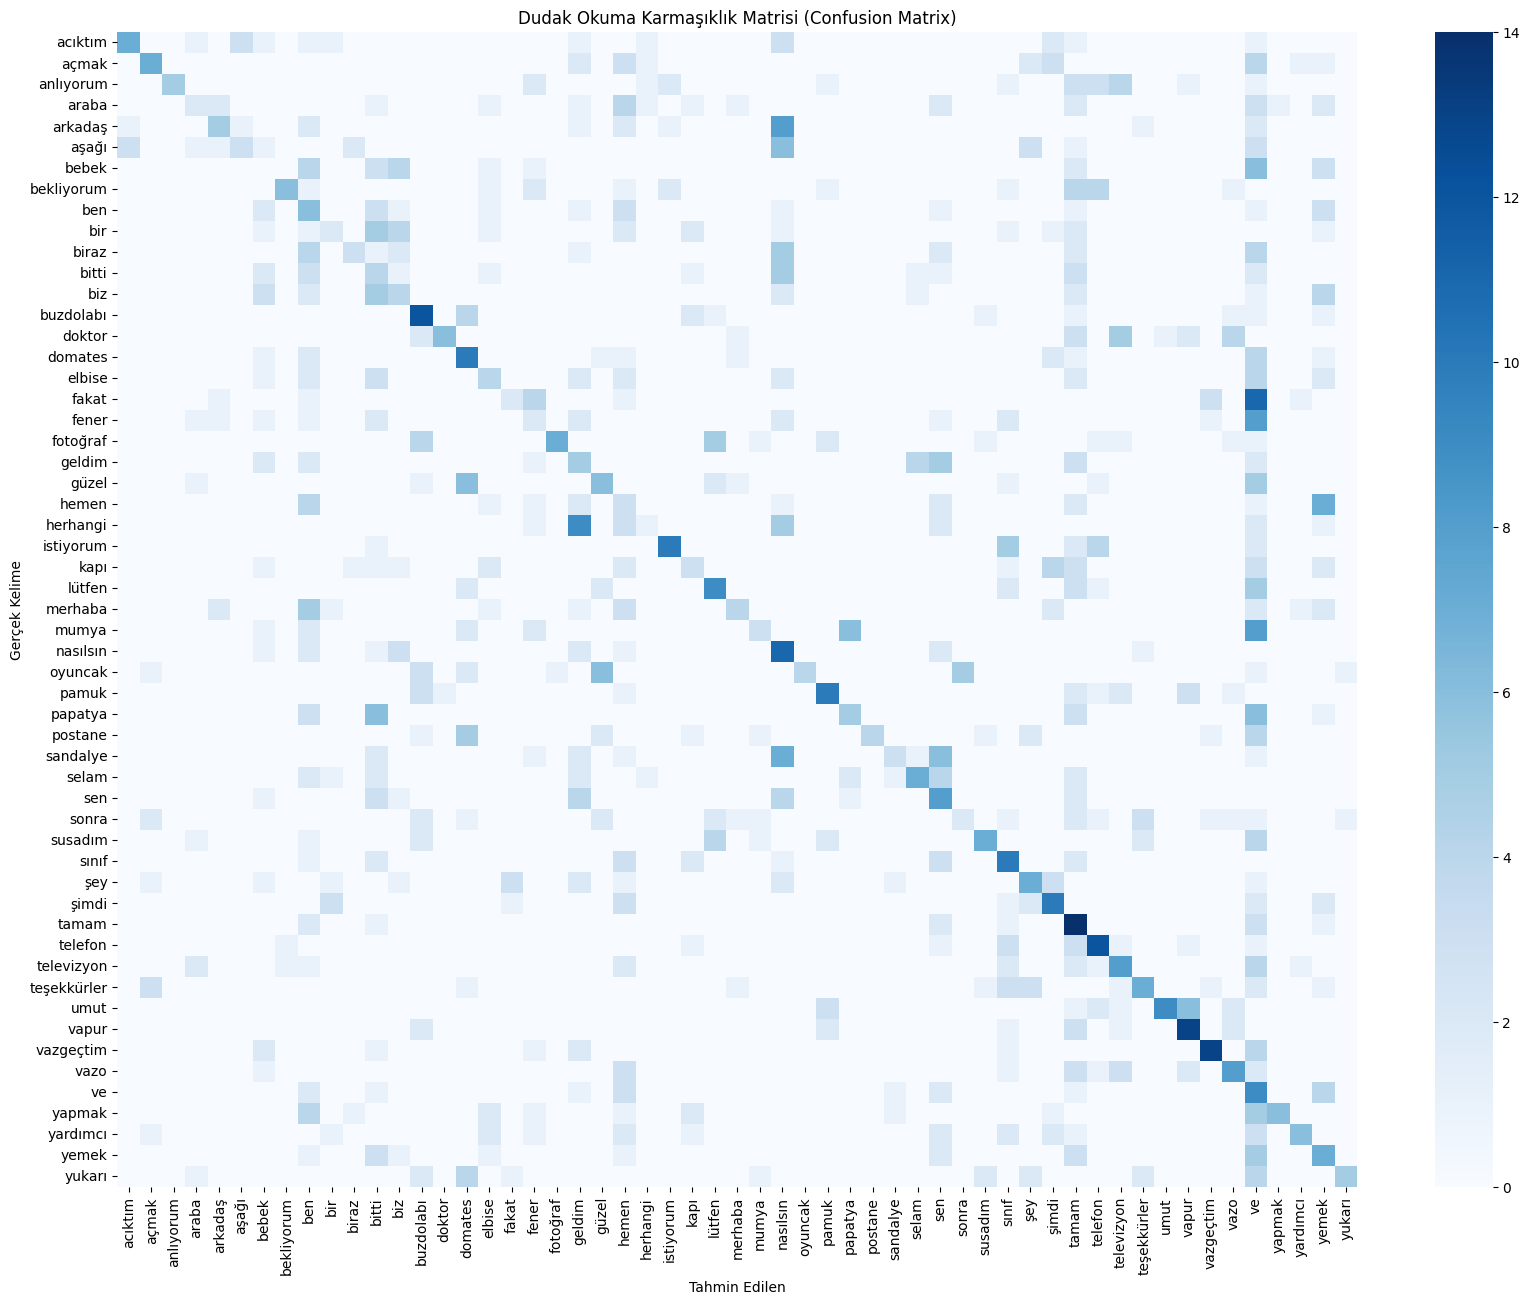

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Tahminleri Topla
all_preds = []
all_labels = []

model.eval()
print("🧪 Test seti üzerinde derinlemesine analiz başlatıldı...")

with torch.no_grad():
    for inputs, labels, lengths in test_loader:
        inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
        outputs = model(inputs, lengths)

        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# 2. Metrikleri Hesapla
# Sınıf isimlerini (kelimeleri) alalım
target_names = [idx2label[i] for i in range(len(label2idx))]

print("\n📜 --- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"🎯 Macro F1-Score: %{macro_f1*100:.2f}")
print(f"⚖️ Weighted F1-Score: %{weighted_f1*100:.2f}")

# 3. Confusion Matrix (Görsel Analiz)
plt.figure(figsize=(20, 15))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Kelime')
plt.title('Dudak Okuma Karmaşıklık Matrisi (Confusion Matrix)')
plt.show()

In [ ]:
import torchvision.transforms as T
import random

class AugmentedLipDataset(MaskedLipDataset):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Sadece "Görsel Çeşitlilik" katan transformlar
        self.aug = T.Compose([
            T.RandomRotation(degrees=5),      # Kafa eğikliğini simüle eder
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1), # Işık değişimleri
            T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.3), # Odaklama hataları
        ])

    def __getitem__(self, idx):
        frames, label, length = super().__getitem__(idx)

        # [T, C, H, W] formatındaki videoya transform uygulama
        if self.data_list[idx] in train_list: # Sadece eğitim setine uygula
            # Rastgele bir açı ve renk ayarı seçip tüm videoya aynı şeyi uygula (tutarlılık için)
            frames = self.aug(frames)

        return frames, label, length

In [ ]:
# 1. Modeli ve Ağırlıkları Yükle
model = modernHybridLipModel(num_classes=55).to(device)
model.load_state_dict(torch.load('best_lip_model.pt', map_location=device))

# 2. Daha Sert Düzenlileştirme (Regularization)
# Weight Decay'i artırarak ağırlıkların "ezberlemesini" engelliyoruz
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.05)
scaler = torch.amp.GradScaler('cuda')

# 3. Yeni Loader'lar (Augmentation eklenmiş haliyle)
train_loader = DataLoader(AugmentedLipDataset(train_list, label2idx, seq_max=75), batch_size=16, shuffle=True)
val_loader = DataLoader(AugmentedLipDataset(val_list, label2idx, seq_max=75), batch_size=16, shuffle=False)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 181MB/s]


In [ ]:
import os

# Yeni refinement dosyaları için ayrı bir klasör
refined_dir = '/content/checkpoints/refined_process'
os.makedirs(refined_dir, exist_ok=True)

print(f"🚀 İyileştirme başladı. Her epoch '{refined_dir}' klasörüne kaydedilecek.")

best_val_acc = 52.47 # Mevcut rekorun

for epoch in range(15):
    model.train()
    train_correct, train_total = 0, 0
    running_loss = 0.0

    for inputs, labels, lengths in train_loader:
        inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(inputs, lengths)
            loss = nn.CrossEntropyLoss(label_smoothing=0.15)(outputs, labels) # Biraz daha sert smoothing

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)
        running_loss += loss.item()

    # Validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for inputs, labels, lengths in val_loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            outputs = model(inputs, lengths)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    v_acc = 100. * val_correct / len(val_list)
    t_acc = 100. * train_correct / train_total

    # --- KAYIT SİSTEMİ ---

    # 1. Her Epoch'u Ayrı Kaydet (Geriye dönüp analiz etmek için)
    epoch_save_path = f'{refined_dir}/refined_epoch_{epoch+1}_acc_{v_acc:.2f}.pt'
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'val_acc': v_acc,
        'train_acc': t_acc
    }, epoch_save_path)

    print(f"📦 Epoch {epoch+1} kaydedildi: {epoch_save_path}")

    # 2. Eğer Rekor Kırılırsa "Best" Olarak Güncelle
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), f'{refined_dir}/refined_BEST_model.pt')
        print(f"⭐ YENİ REKOR! %{v_acc:.2f} ile en iyi model güncellendi.")

    print(f"🔥 Epoch {epoch+1:02d} | Train: %{t_acc:.2f} | Val: %{v_acc:.2f} | Loss: {running_loss/len(train_loader):.4f}")

🚀 İyileştirme başladı. Her epoch '/content/checkpoints/refined_process' klasörüne kaydedilecek.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


📦 Epoch 1 kaydedildi: /content/checkpoints/refined_process/refined_epoch_1_acc_58.44.pt
⭐ YENİ REKOR! %58.44 ile en iyi model güncellendi.
🔥 Epoch 01 | Train: %64.15 | Val: %58.44 | Loss: 2.0303
📦 Epoch 2 kaydedildi: /content/checkpoints/refined_process/refined_epoch_2_acc_57.32.pt
🔥 Epoch 02 | Train: %82.24 | Val: %57.32 | Loss: 1.4880
📦 Epoch 3 kaydedildi: /content/checkpoints/refined_process/refined_epoch_3_acc_58.44.pt
🔥 Epoch 03 | Train: %87.90 | Val: %58.44 | Loss: 1.3554
📦 Epoch 4 kaydedildi: /content/checkpoints/refined_process/refined_epoch_4_acc_59.83.pt
⭐ YENİ REKOR! %59.83 ile en iyi model güncellendi.
🔥 Epoch 04 | Train: %90.81 | Val: %59.83 | Loss: 1.2805
📦 Epoch 5 kaydedildi: /content/checkpoints/refined_process/refined_epoch_5_acc_58.96.pt
🔥 Epoch 05 | Train: %93.09 | Val: %58.96 | Loss: 1.2360
📦 Epoch 6 kaydedildi: /content/checkpoints/refined_process/refined_epoch_6_acc_60.09.pt
⭐ YENİ REKOR! %60.09 ile en iyi model güncellendi.
🔥 Epoch 06 | Train: %94.63 | Val: %60.0

KeyboardInterrupt: 

In [ ]:
# Eğer label2idx hala hafızada yoksa, önce sınıf listenden onu tekrar oluşturmalısın.
# Ama muhtemelen label2idx duruyordur, sadece tersi (idx2label) eksiktir:

if 'label2idx' in locals():
    idx2label = {v: k for k, v in label2idx.items()}
    print(f"✅ Sözlük başarıyla kurtarıldı. {len(idx2label)} kelime eşleştirildi.")
else:
    # Eğer label2idx da gitmişse, kelime listeni buraya koyup tekrar oluştur:
    # classes = ["acıktım", "açmak", "anlıyorum", ...] # 55 kelimelik listen
    # label2idx = {word: i for i, word in enumerate(sorted(classes))}
    # idx2label = {i: word for i, word in enumerate(sorted(classes))}
    print("⚠️ Dikkat: label2idx da bulunamadı! Lütfen veri setini hazırladığın hücreyi tekrar çalıştır.")

✅ Sözlük başarıyla kurtarıldı. 55 kelime eşleştirildi.


🧪 Yeni 'Best Model' ile test seti taranıyor...

📜 --- REFINED MODEL CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

      acıktım       0.61      0.48      0.54        23
       açmak       0.94      0.62      0.75        24
    anlıyorum       0.52      0.62      0.57        24
        araba       0.20      0.38      0.26        24
     arkadaş       0.67      0.67      0.67        24
      aşağı       0.62      0.54      0.58        24
        bebek       0.17      0.21      0.19        24
   bekliyorum       0.95      0.79      0.86        24
          ben       0.32      0.50      0.39        24
          bir       0.36      0.42      0.38        24
        biraz       0.86      0.25      0.39        24
        bitti       0.19      0.21      0.20        24
          biz       0.30      0.38      0.33        24
    buzdolabı       0.82      0.75      0.78        24
       doktor       0.80      0.83      0.82        24
      domates       0.63 

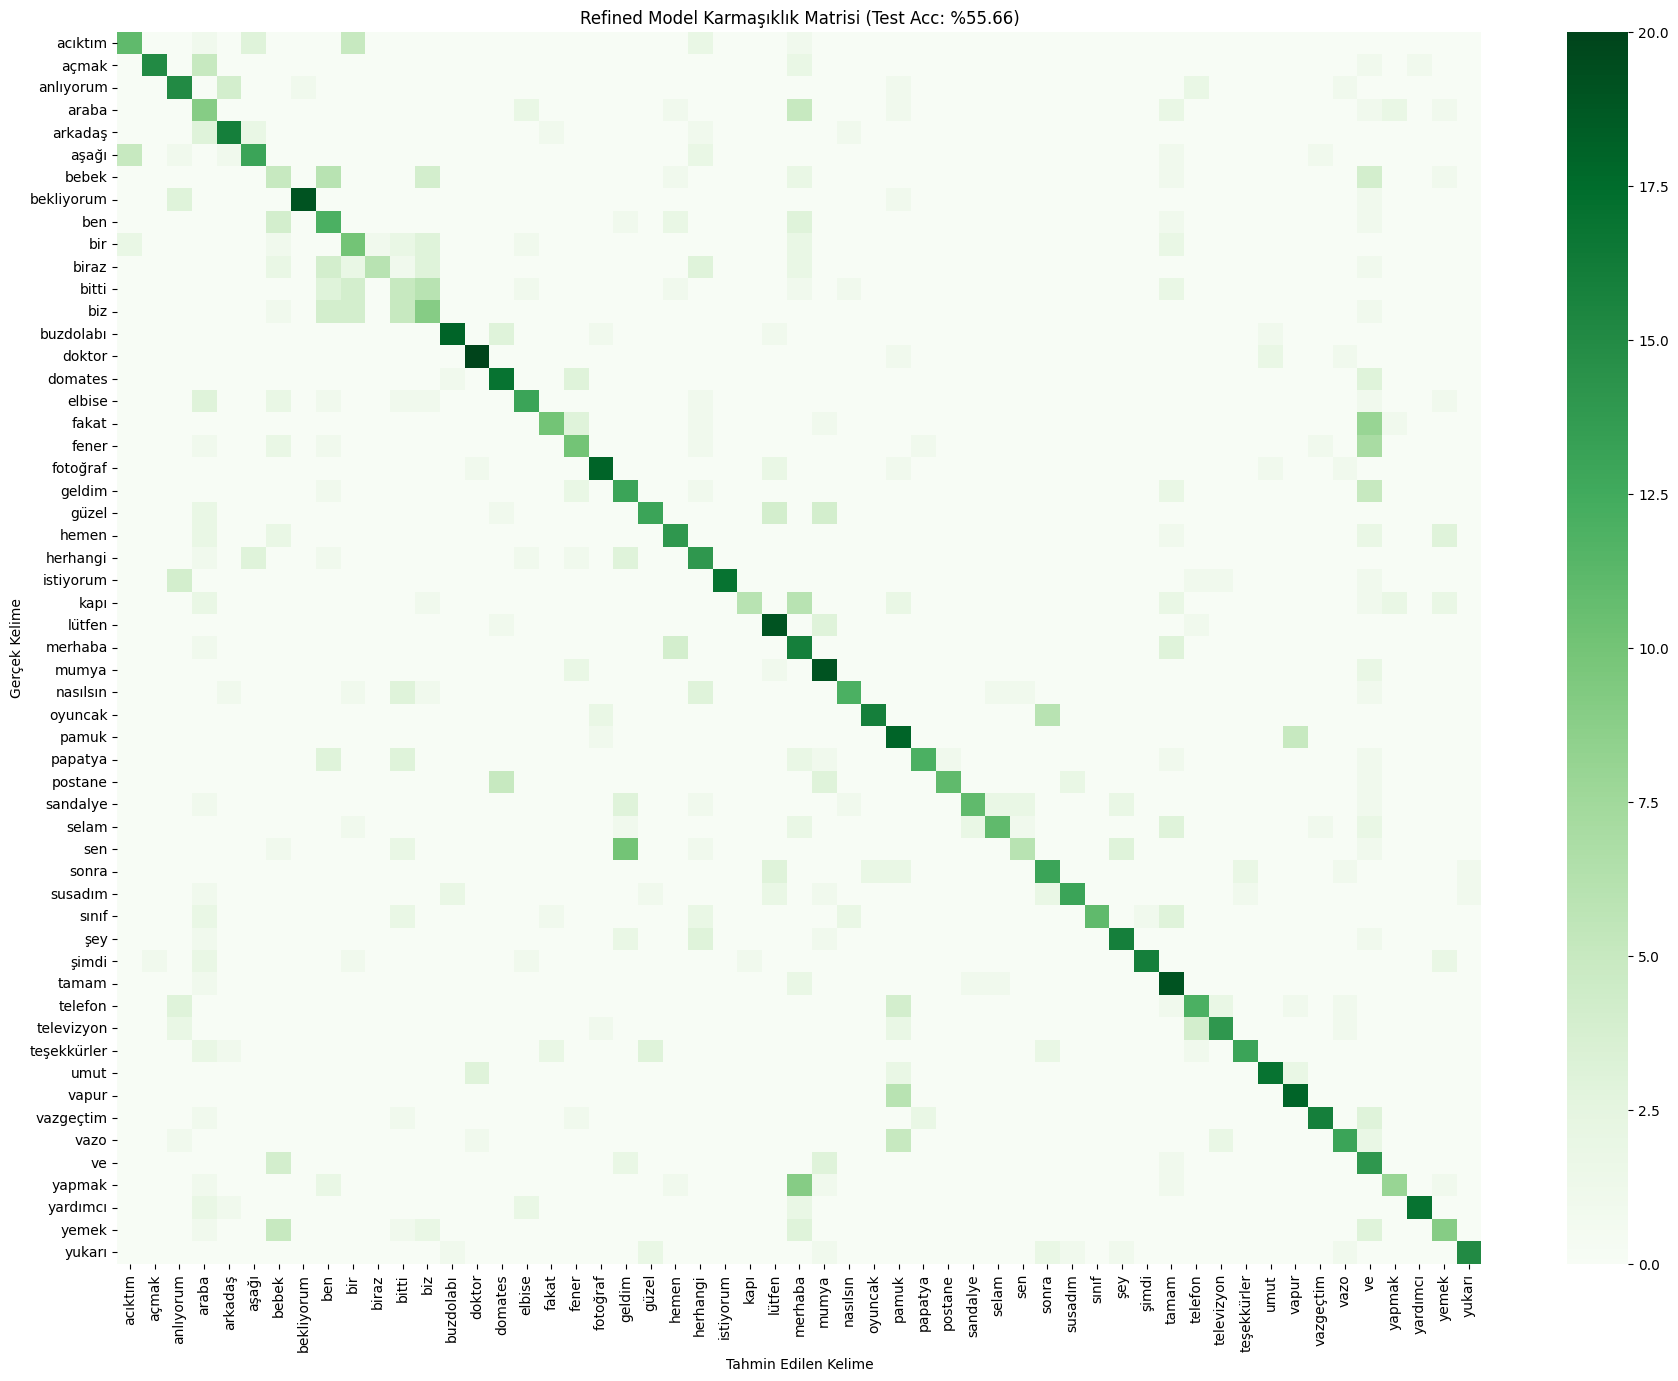

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1. Modeli ve En İyi Ağırlıkları Yükle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = modernHybridLipModel(num_classes=55).to(device)

# Refined best modelin yolunu buraya yaz (Drive'da ise yolu güncelle)
best_model_path = '/content/checkpoints/refined_process/refined_BEST_model.pt'
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# 2. Test Loader Hazırla
test_loader = DataLoader(
    MaskedLipDataset(test_list, label2idx, seq_max=75),
    batch_size=16,
    shuffle=False
)

# 3. Tahminleri Topla
all_preds = []
all_labels = []

print("🧪 Yeni 'Best Model' ile test seti taranıyor...")

with torch.no_grad():
    for inputs, labels, lengths in test_loader:
        inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
        outputs = model(inputs, lengths)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# 4. Raporlama
target_names = [idx2label[i] for i in range(len(label2idx))]
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n📜 --- REFINED MODEL CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=target_names))
print(f"🎯 Final Macro F1-Score: %{macro_f1*100:.2f}")

# 5. Confusion Matrix Görselleştirme
plt.figure(figsize=(22, 16))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=False, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Tahmin Edilen Kelime')
plt.ylabel('Gerçek Kelime')
plt.title(f'Refined Model Karmaşıklık Matrisi (Test Acc: %{100*np.sum(np.array(all_preds)==np.array(all_labels))/len(all_labels):.2f})')
plt.show()

In [ ]:
import random

def run_sample_tests(num_samples=10):
    model.eval()
    samples = random.sample(test_list, num_samples) # Test setinden rastgele seçim
    test_dataset = MaskedLipDataset(samples, label2idx, seq_max=75)

    print(f"🔍 {num_samples} adet rastgele test videosu işleniyor...\n")
    print(f"{'GERÇEK KELİME':<20} | {'MODEL TAHMİNİ':<20} | {'DURUM'}")
    print("-" * 55)

    with torch.no_grad():
        for i in range(num_samples):
            frames, label, length = test_dataset[i]
            input_tensor = frames.unsqueeze(0).to(device)
            length_tensor = torch.tensor([length]).to(device)

            outputs = model(input_tensor, length_tensor)
            prediction = torch.argmax(outputs, dim=1).item()

            true_word = idx2label[label.item()]
            pred_word = idx2label[prediction]

            status = "✅ DOĞRU" if true_word == pred_word else "❌ HATALI"
            print(f"{true_word:<20} | {pred_word:<20} | {status}")

# Testi ateşleyelim
run_sample_tests(10)

🔍 10 adet rastgele test videosu işleniyor...

GERÇEK KELİME        | MODEL TAHMİNİ        | DURUM
-------------------------------------------------------
fakat                | ve                   | ❌ HATALI
oyuncak              | fotoğraf            | ❌ HATALI
yukarı               | şey                 | ❌ HATALI
buzdolabı            | buzdolabı            | ✅ DOĞRU
biz                  | biz                  | ✅ DOĞRU
fakat                | fakat                | ✅ DOĞRU
fotoğraf            | fotoğraf            | ✅ DOĞRU
nasılsın             | bitti                | ❌ HATALI
biz                  | ben                  | ❌ HATALI
sandalye             | sandalye             | ✅ DOĞRU


In [ ]:
def calculate_top_k_accuracy(k_list=[1, 2, 3, 5]):
    model.eval()
    results = {k: 0 for k in k_list}
    total = 0

    print(f"🔍 Top-K analizi yapılıyor (K: {k_list})...")

    with torch.no_grad():
        for inputs, labels, lengths in test_loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            outputs = model(inputs, lengths) # Softmax öncesi logit'ler

            # Her bir K değeri için doğruluğu hesapla
            for k in k_list:
                _, topk_preds = outputs.topk(k, dim=1) # En yüksek K tahmini al
                correct = topk_preds.eq(labels.view(-1, 1).expand_as(topk_preds))
                results[k] += correct.any(dim=1).sum().item()

            total += labels.size(0)

    print(f"\n📊 --- TOP-K ACCURACY SONUÇLARI (Test Seti) ---")
    for k in k_list:
        acc = 100. * results[k] / total
        print(f"🎯 Top-{k} Accuracy: %{acc:.2f}")

calculate_top_k_accuracy()

🔍 Top-K analizi yapılıyor (K: [1, 2, 3, 5])...

📊 --- TOP-K ACCURACY SONUÇLARI (Test Seti) ---
🎯 Top-1 Accuracy: %55.66
🎯 Top-2 Accuracy: %70.77
🎯 Top-3 Accuracy: %78.36
🎯 Top-5 Accuracy: %84.74


In [ ]:
import torch.nn.functional as F

def run_top5_detailed_tests(num_samples=5):
    model.eval()
    samples = random.sample(test_list, num_samples)
    test_dataset = MaskedLipDataset(samples, label2idx, seq_max=75)

    print(f"🔍 {num_samples} adet video için Top-5 aday listesi:\n")

    with torch.no_grad():
        for i in range(num_samples):
            frames, label, length = test_dataset[i]
            input_tensor = frames.unsqueeze(0).to(device)
            length_tensor = torch.tensor([length]).to(device)

            outputs = model(input_tensor, length_tensor)
            # İhtimalleri hesapla (Softmax)
            probs = F.softmax(outputs, dim=1)

            # En yüksek 5 ihtimali ve indexi al
            top5_probs, top5_inds = torch.topk(probs, 5)

            true_word = idx2label[label.item()]

            print(f"🎬 Gerçek Kelime: **{true_word.upper()}**")
            print(f"{'Sıra':<5} | {'Tahmin Edilen':<15} | {'Güven Oranı (Confidence)'}")
            print("-" * 45)

            for rank in range(5):
                p = top5_probs[0][rank].item()
                idx = top5_inds[0][rank].item()
                word = idx2label[idx]

                status = "⭐" if word == true_word else "  "
                print(f"{rank+1:<5} | {word:<15} {status} | %{p*100:.2f}")
            print("\n" + "="*50 + "\n")

# Analizi başlatalım
run_top5_detailed_tests(5)

🔍 5 adet video için Top-5 aday listesi:

🎬 Gerçek Kelime: **POSTANE**
Sıra  | Tahmin Edilen   | Güven Oranı (Confidence)
---------------------------------------------
1     | postane         ⭐ | %69.28
2     | domates            | %6.42
3     | şey               | %3.94
4     | bitti              | %1.57
5     | şimdi             | %1.09


🎬 Gerçek Kelime: **AŞAĞI**
Sıra  | Tahmin Edilen   | Güven Oranı (Confidence)
---------------------------------------------
1     | acıktım            | %61.12
2     | bir                | %6.91
3     | selam              | %4.66
4     | ben                | %1.97
5     | herhangi           | %1.81


🎬 Gerçek Kelime: **ISTIYORUM**
Sıra  | Tahmin Edilen   | Güven Oranı (Confidence)
---------------------------------------------
1     | istiyorum       ⭐ | %80.90
2     | bekliyorum         | %2.58
3     | selam              | %1.40
4     | teşekkürler      | %0.50
5     | tamam              | %0.50


🎬 Gerçek Kelime: **BEBEK**
Sıra  | Tahmin Edile